In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '/home/ferjao_k/sw/aare/build')
from aare import Pol1, Pol2

## Ground truth


In [2]:
x = np.linspace(0, 10, 50)
 
# Pol1: y = 3.0 + 1.5*x
true_pol1 = [3.0, 1.5]
y_pol1 = true_pol1[0] + true_pol1[1] * x
y_pol1_noisy = y_pol1 + np.random.default_rng(42).normal(0, 0.5, x.size)
 
# Pol2: y = 2.0 - 0.5*x + 0.3*x^2
true_pol2 = [2.0, -0.5, 0.3]
y_pol2 = true_pol2[0] + true_pol2[1] * x + true_pol2[2] * x**2
y_pol2_noisy = y_pol2 + np.random.default_rng(7).normal(0, 1.0, x.size)

## Fit with error estimation

In [11]:
m1 = Pol1()
m2 = Pol2()
 
res1 = m1.fit(x, y_pol1_noisy)
res2 = m2.fit(x, y_pol2_noisy)

p1 = res1['par']
print("=== Pol1 ===")
print(f"  True:   p0={true_pol1[0]:.4f}  p1={true_pol1[1]:.4f}")
print(f"  Fitted: p0={p1[0]:.4f}  p1={p1[1]:.4f}")
print(f"  Chi2:   {res1['chi2']}")
print()

p2 = res2['par']
print("=== Pol2 ===")
print(f"  True:   p0={true_pol2[0]:.4f}  p1={true_pol2[1]:.4f}  p2={true_pol2[2]:.4f}")
print(f"  Fitted: p0={p2[0]:.4f}  p1={p2[1]:.4f}  p2={p2[2]:.4f}")
print(f"  Chi2:   {res2['chi2']}")

=== Pol1 ===
  True:   p0=3.0000  p1=1.5000
  Fitted: p0=2.9325  p1=1.5226
  Chi2:   [7.00870822]

=== Pol2 ===
  True:   p0=2.0000  p1=-0.5000  p2=0.3000
  Fitted: p0=2.1391  p1=-0.8442  p2=0.3383
  Chi2:   [34.11224393]


## Plot

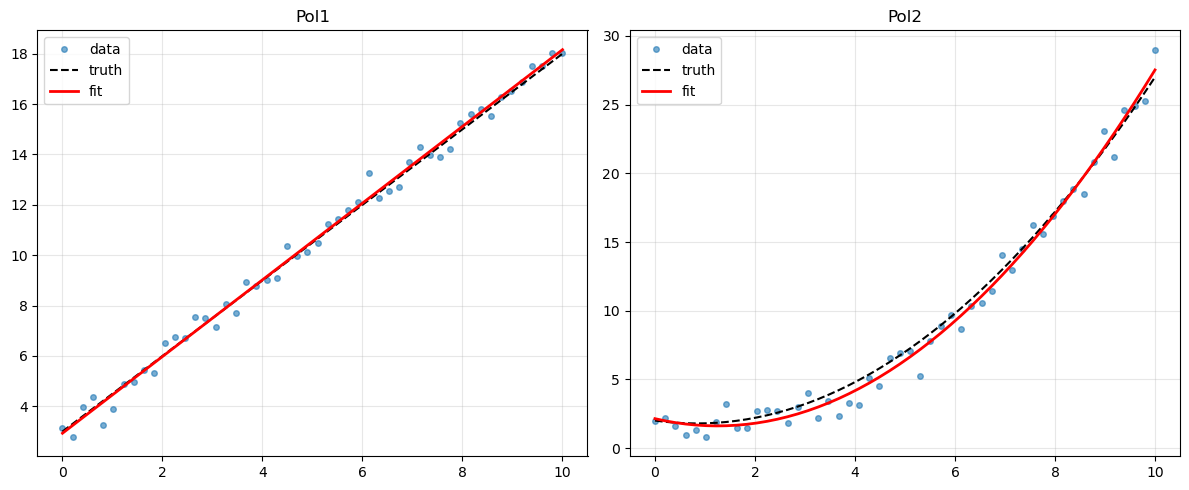

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
 
# Pol1
ax1.plot(x, y_pol1_noisy, 'o', ms=4, alpha=0.6, label='data')
ax1.plot(x, y_pol1, 'k--', label='truth')
ax1.plot(x, m1(x, res1['par']), 'r-', lw=2, label='fit')
ax1.set_title('Pol1')
ax1.legend()
ax1.grid(alpha=0.3)
 
# Pol2
ax2.plot(x, y_pol2_noisy, 'o', ms=4, alpha=0.6, label='data')
ax2.plot(x, y_pol2, 'k--', label='truth')
ax2.plot(x, m2(x, res2['par']), 'r-', lw=2, label='fit')
ax2.set_title('Pol2')
ax2.legend()
ax2.grid(alpha=0.3)
 
fig.tight_layout()
plt.show()